# TA7 - Trackstars

Rubric 
- A python package for feature engineering is demonstrated
- A small dataset for testing purposes is either a built-in dataset, accessible via a python package, or added to the data/ repository
- Code is a script, not a notebook
- Code is clean and well organized
- Code is documented with docstrings and comments 
- Code is free of commented out code (ie debug print statements)
- Script has a clear name
- Branching and PRs were done appropriately
- Requirements are included in the text of the PR and are correct and versioned
- The code runs as documented

❗️ Any demo code will need to be migrated to a streamlit app or similar for the assignment. 

In [1]:
# The instinct here is to engineer general and dataset-specific features 
# that might improve our ability to do classification with this dataset

In [2]:
# See overview of pytorch dataset interactions here: 
# https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

import torch 
from torch.utils.data import Dataset
from torchvision.datasets import INaturalist

import cv2

In [3]:
import matplotlib.pyplot as plt 

In [158]:
# See overview of built-in INaturalist dataset interface here: 
# https://pytorch.org/vision/stable/generated/torchvision.datasets.INaturalist.html#torchvision.datasets.INaturalist
#
# ... and the included competition datasets and their structure here: 
# https://github.com/visipedia/inat_comp/tree/master
#
# ... and the implementation here: 
# https://pytorch.org/vision/0.12/_modules/torchvision/datasets/inaturalist.html

# Suggest we focus on 2021 competition 'mini' dataset, 50 examples each of 10,000 species: 
# https://github.com/visipedia/inat_comp/tree/master/2021
training_data = INaturalist(
    root='inaturalist', 
    version='2021_train_mini', 
    target_type='class'
) 

In [159]:
# 500K images... 

In [160]:
len(training_data) 

500000

In [161]:
# 10000 species... 

In [162]:
len(training_data.all_categories) 

10000

In [163]:
# Dataset has an image and an int, these can be retrieved by indexing the 
# object or passing an index to __getitem__ ... 

In [164]:
training_data[0]

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=375x500>, 0)

In [165]:
display(training_data.__getitem__(0))

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=375x500>, 0)

In [166]:
sample = training_data[1459]

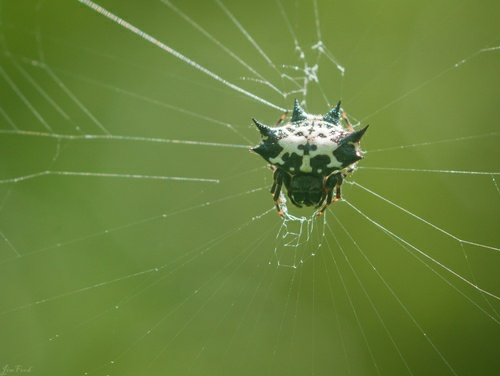

In [167]:
# Image in the first part of the tuple... 
sample[0]

In [168]:
# 'Target' appears to be encoded in the int, we specified 'class' above so 
# presume this is the class of this image
sample[1]

2

In [169]:
training_data.category_name('class',sample[1]) 

'Arachnida'

Utility function to dump the same info... 

In [170]:
def render_sample(index, target): 
    sample = training_data[index] 
    print(f"{target} of sample #{index} is {training_data.category_name(target, sample[1])}")     
    display(sample[0])

class of sample #1000 is Arachnida


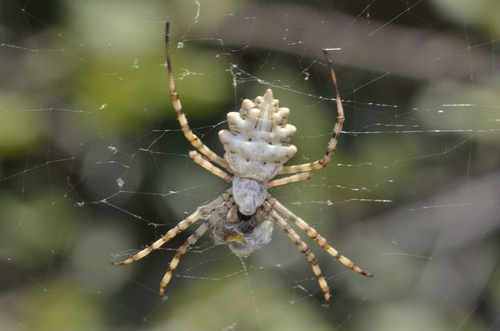

In [171]:
render_sample(1000, 'class')

In [172]:
# The target_type used on initialization probably is what sets the 
# integer value in the tuple. If we use the integer returned with the 
# sample and specify a different target/category we get a mismatch... 

kingdom of sample #1003 is Plantae


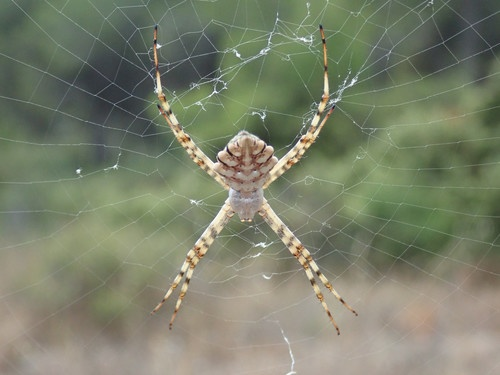

In [173]:
render_sample(1003, 'kingdom') 

In [174]:
# Complete categorization is available for every entry, but mapping must be 
# done on initialization, because these don't correlate to our sample indices
training_data.all_categories[1000:1005]

['01000_Animalia_Arthropoda_Insecta_Lepidoptera_Erebidae_Catocala_maestosa',
 '01001_Animalia_Arthropoda_Insecta_Lepidoptera_Erebidae_Catocala_micronympha',
 '01002_Animalia_Arthropoda_Insecta_Lepidoptera_Erebidae_Catocala_neogama',
 '01003_Animalia_Arthropoda_Insecta_Lepidoptera_Erebidae_Catocala_nupta',
 '01004_Animalia_Arthropoda_Insecta_Lepidoptera_Erebidae_Catocala_piatrix']